<a href="https://colab.research.google.com/github/khanuja74/khanuja74/blob/main/Ecommerce_Furniture_Analysis_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:27: SyntaxWarning: invalid escape sequence '\$'
<>:28: SyntaxWarning: invalid escape sequence '\$'
<>:27: SyntaxWarning: invalid escape sequence '\$'
<>:28: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-3776605875.py:27: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
/tmp/ipython-input-3776605875.py:28: SyntaxWarning: invalid escape sequence '\$'
  df['originalPrice'] = df['originalPrice'].replace('[\$,]', '', regex=True).astype(float)


✅ Data Loaded Successfully!

Shape of Dataset: (2000, 5)

Preview of Data:
                                        productTitle originalPrice    price  \
0  Dresser For Bedroom With 9 Fabric Drawers Ward...           $30   $46.79   
1  Outdoor Conversation Set 4 Pieces Patio Furnit...          $116  $169.72   
2  Desser For Bedroom With 7 Fabric Drawers Organ...         $78.4   $39.46   
3  Modern Accent Boucle Chair,Upholstered Tufted ...           $89  $111.99   
4  Small Unit Simple Computer Desk Household Wood...        $48.82   $21.37   

   sold        tagText  
0   600  Free shipping  
1     9  Free shipping  
2     7  Free shipping  
3     2  Free shipping  
4     1  Free shipping  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   productTitle   2000 non-null   object
 1   originalPrice  498 non-null    object


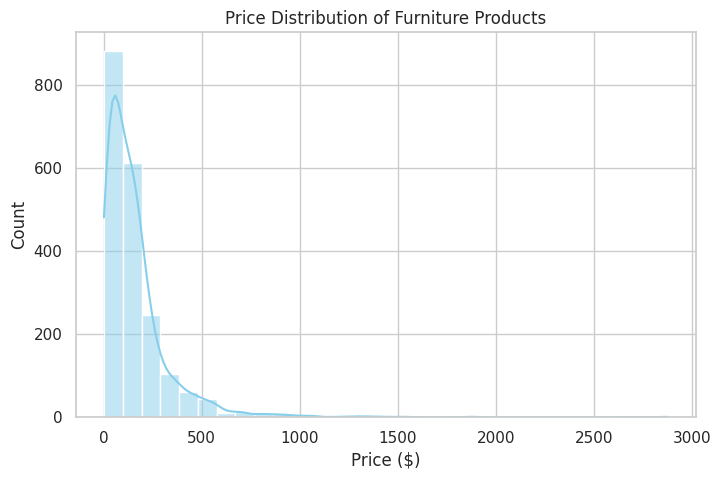

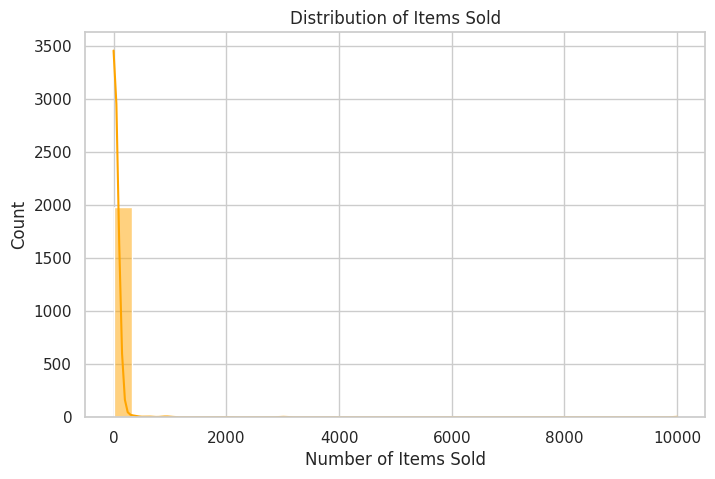

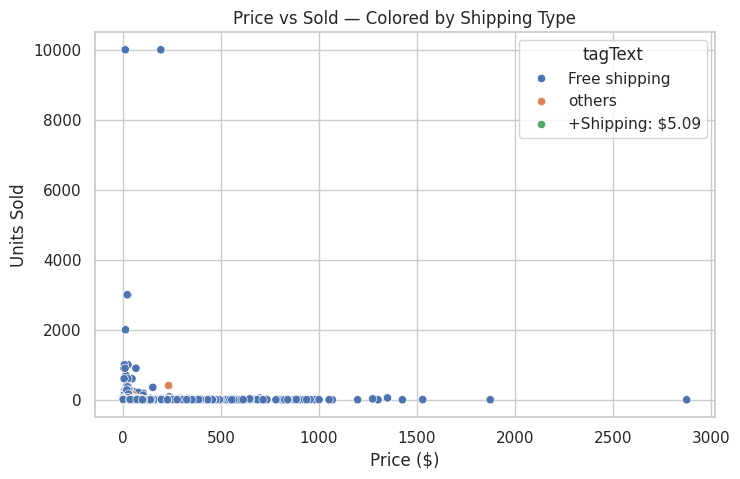

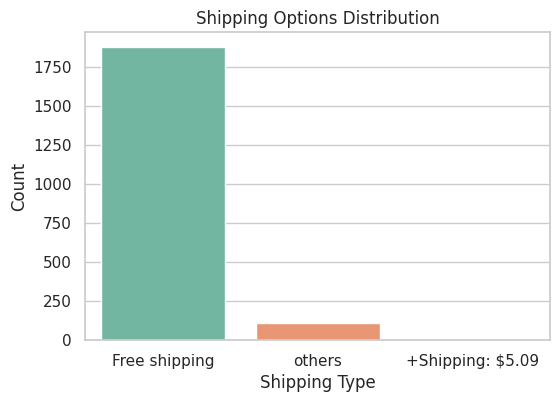


✅ Feature Engineering Completed!
   originalPrice   price  sold  tagText  discount_percentage  adjustable  and  \
0           30.0   46.79   600        1           -55.966667         0.0  0.0   
1          116.0  169.72     9        1           -46.310345         0.0  0.0   
2           78.4   39.46     7        1            49.668367         0.0  0.0   

   bed   bedroom  bedside  ...   up  upholstered  vanity  velvet  wardrobe  \
0  0.0  0.189721      0.0  ...  0.0          0.0     0.0     0.0  0.300611   
1  0.0  0.000000      0.0  ...  0.0          0.0     0.0     0.0  0.000000   
2  0.0  0.200469      0.0  ...  0.0          0.0     0.0     0.0  0.000000   

   white    wicker      with  wood  wooden  
0    0.0  0.000000  0.120182   0.0     0.0  
1    0.0  0.300086  0.000000   0.0     0.0  
2    0.0  0.000000  0.126991   0.0     0.0  

[3 rows x 105 columns]

📈 MODEL PERFORMANCE:
Linear Regression → MSE: 13739.07, R²: -1.506
Random Forest → MSE: 18206.61, R²: -2.320

📊 INSIGHTS:
1

In [1]:

# 🛋️ E-COMMERCE FURNITURE DATASET 2024 — DATA ANALYSIS + ML PROJECT

# 1️⃣ Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# 2️⃣ Load the Dataset
df = pd.read_csv("ecommerce_furniture_dataset_2024.csv")
print("✅ Data Loaded Successfully!\n")
print("Shape of Dataset:", df.shape)
print("\nPreview of Data:")
print(df.head())

# 3️⃣ Data Overview
print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# 4️⃣ Data Cleaning
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df['originalPrice'] = df['originalPrice'].replace('[\$,]', '', regex=True).astype(float)
df['originalPrice'].fillna(df['originalPrice'].mean(), inplace=True)

df['tagText'] = df['tagText'].apply(lambda x: x if x in ['Free shipping', '+Shipping: $5.09'] else 'others')

print("\n✅ Cleaned Data Sample:")
print(df.head())

# 5️⃣ Exploratory Data Analysis (EDA)
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True, color='skyblue')
plt.title("Price Distribution of Furniture Products")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['sold'], bins=30, kde=True, color='orange')
plt.title("Distribution of Items Sold")
plt.xlabel("Number of Items Sold")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x='price', y='sold', hue='tagText', data=df)
plt.title("Price vs Sold — Colored by Shipping Type")
plt.xlabel("Price ($)")
plt.ylabel("Units Sold")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='tagText', data=df, palette='Set2')
plt.title("Shipping Options Distribution")
plt.xlabel("Shipping Type")
plt.ylabel("Count")
plt.show()

# 6️⃣ Feature Engineering
df['discount_percentage'] = ((df['originalPrice'] - df['price']) / df['originalPrice']) * 100

from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=100)
title_features = tfidf.fit_transform(df['productTitle'].astype(str))
title_df = pd.DataFrame(title_features.toarray(), columns=tfidf.get_feature_names_out())
df = pd.concat([df, title_df], axis=1)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['tagText'] = le.fit_transform(df['tagText'])

df.drop(['productTitle'], axis=1, inplace=True)

print("\n✅ Feature Engineering Completed!")
print(df.head(3))

# 7️⃣ Model Training — Predict Number of Items Sold
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

X = df.drop('sold', axis=1)
y = df['sold']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# 8️⃣ Model Evaluation
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n📈 MODEL PERFORMANCE:")
print(f"Linear Regression → MSE: {mse_lr:.2f}, R²: {r2_lr:.3f}")
print(f"Random Forest → MSE: {mse_rf:.2f}, R²: {r2_rf:.3f}")

# 9️⃣ Key Insights
print("\n📊 INSIGHTS:")
print(f"1️⃣ Total Products: {len(df)}")
print(f"2️⃣ Average Price: ${df['price'].mean():.2f}")
print(f"3️⃣ Average Discount: {df['discount_percentage'].mean():.2f}%")
print(f"4️⃣ Most Common Shipping Type: {le.inverse_transform([df['tagText'].mode()[0]])[0]}")

# 🔟 Save Cleaned Dataset
df.to_csv("Cleaned_Ecommerce_Furniture_Data.csv", index=False)
print("\n💾 Cleaned data saved as 'Cleaned_Ecommerce_Furniture_Data.csv'")
